<a href="https://colab.research.google.com/github/Stephen-2-byte/crop-yield-prediction-ml/blob/main/BlocksYieldCorrelation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Flushing - NDVI R² = 0.021444284149672997
Flushing - GNDVI R² = 0.07602630477854273
Flushing - EVI R² = 0.11451375511563291
Flowering - NDVI R² = 0.2260223867951743
Flowering - GNDVI R² = 0.10308292067379529
Flowering - EVI R² = 0.26494033859236
Fruit Development - NDVI R² = 0.07976587775393414
Fruit Development - GNDVI R² = 0.046540827278747844
Fruit Development - EVI R² = 0.07623330701364776


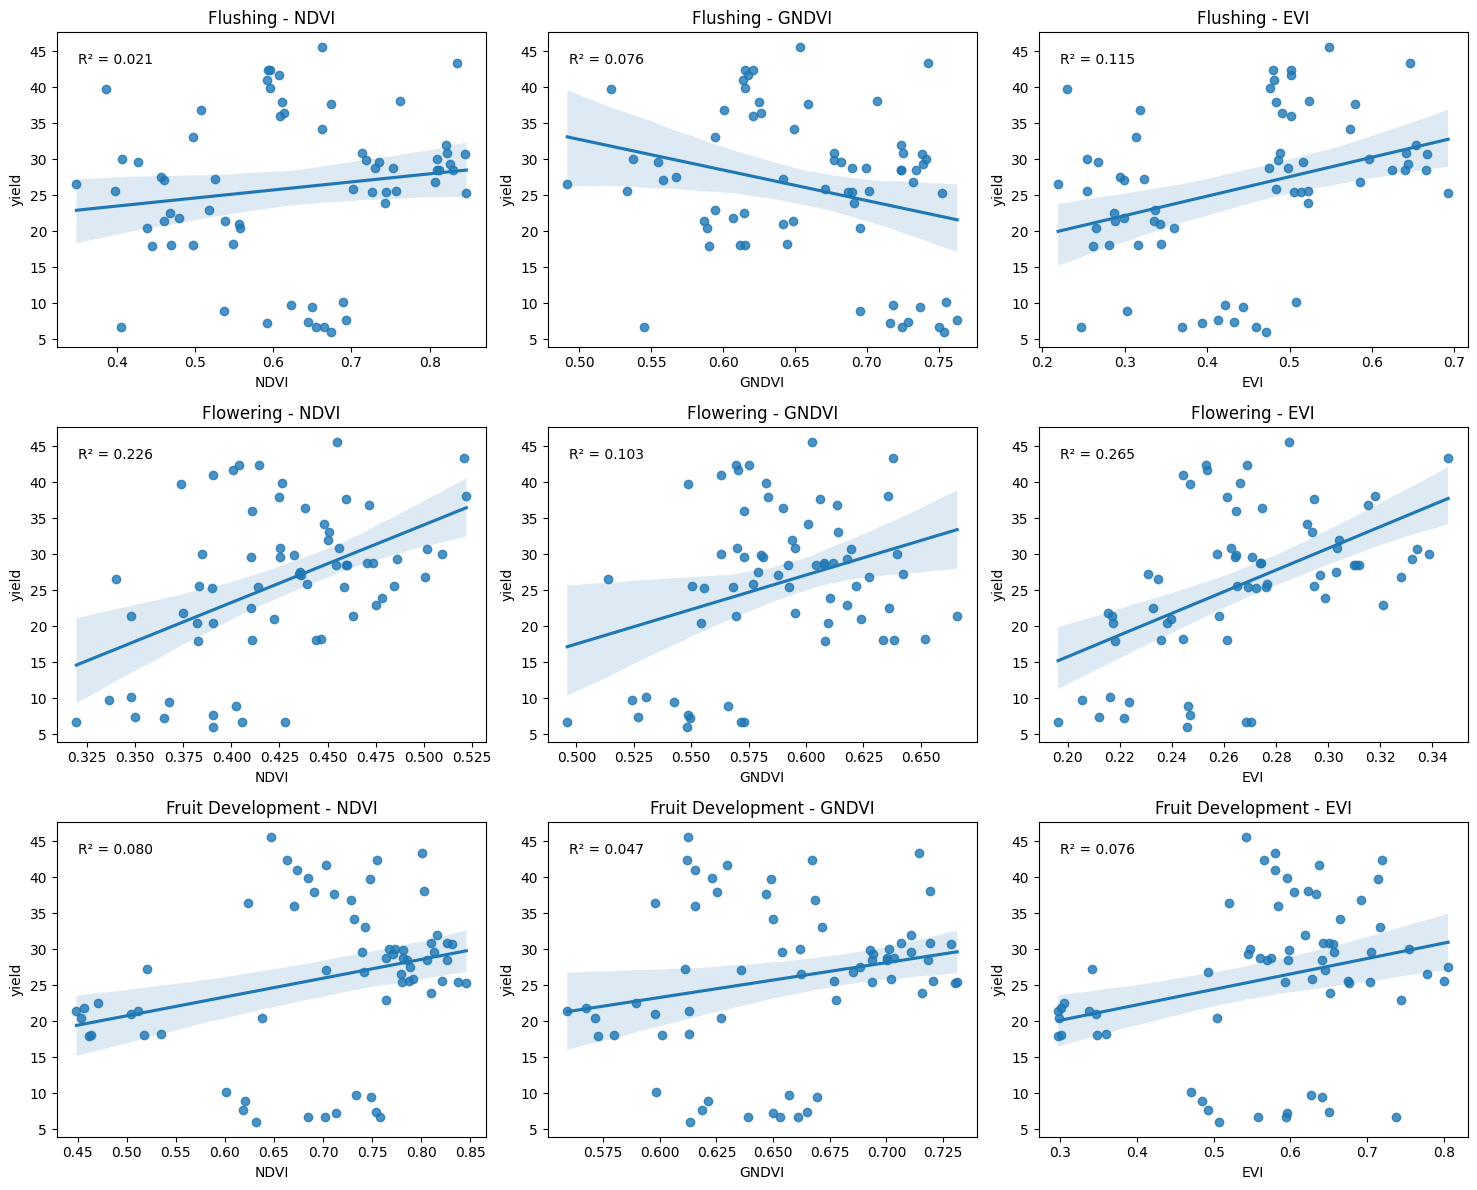

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/VIS_YIELDFinal.csv")

stages = ["Flushing","Flowering","Fruit Development"]
vis = ["NDVI","GNDVI","EVI"]

fig, axes = plt.subplots(3,3, figsize=(15,12))

for i, stage in enumerate(stages):

    stage_data = df[df["Stage"] == stage]

    for j, vi in enumerate(vis):

        ax = axes[i,j]

        sns.regplot(x=vi, y="yield", data=stage_data, ax=ax)

        # correlation
        r = stage_data[vi].corr(stage_data["yield"])

        # coefficient of determination
        r2 = r**2

        # print results
        print(f"{stage} - {vi} R² = {r2}")

        # plot title
        ax.set_title(f"{stage} - {vi}")

        # display R² on plot
        ax.text(0.05, 0.9, f"R² = {r2:.3f}", transform=ax.transAxes)

# Save the figure
plt.tight_layout()
plt.savefig("/content/VI_vs_Yield.png", dpi=300)  # Save as PNG with high resolution
plt.show()

In [ ]:
from google.colab import files
files.download("/content/VI_vs_Yield.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

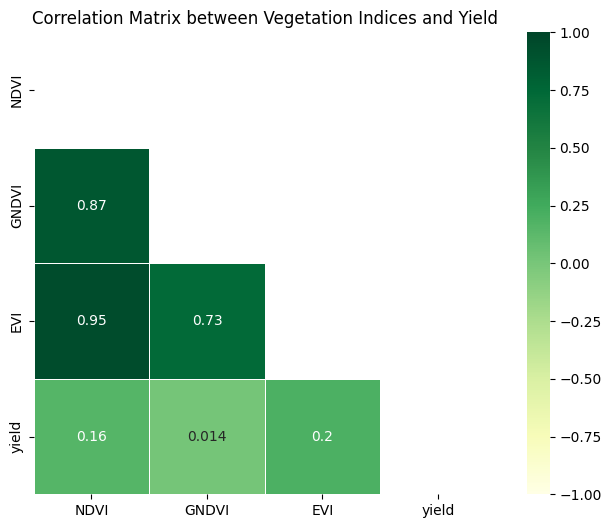

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("/content/VIS_YIELDFinal.csv")

# Select variables for correlation
vars_corr = df[["NDVI","GNDVI","EVI","yield"]]

# Compute correlation matrix
corr = vars_corr.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="YlGn",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix between Vegetation Indices and Yield")

plt.show()

In [ ]:
# ================================
# Stage-wise correlation matrix
# ================================
stages = ["Flushing","Flowering","Fruit Development"]
vis = ["NDVI","GNDVI","EVI"]

stage_corrs = {}

for stage in stages:
    stage_data = df[df["Stage"] == stage]

    # Compute correlation matrix between VIs and yield only
    corr = stage_data[vis + ["yield"]].corr().loc["yield", vis]
    stage_corrs[stage] = corr

# Convert to DataFrame for easy viewing
stage_corr_df = pd.DataFrame(stage_corrs).T  # Transpose so stages are rows

print("Stage-wise Correlation between Yield and Vegetation Indices")
print(stage_corr_df)

Stage-wise Correlation between Yield and Vegetation Indices
                       NDVI     GNDVI       EVI
Flushing           0.146439 -0.275729  0.338399
Flowering          0.475418  0.321065  0.514724
Fruit Development  0.282429  0.215733  0.276104


                       NDVI     GNDVI       EVI
Flushing           0.146439 -0.275729  0.338399
Flowering          0.475418  0.321065  0.514724
Fruit Development  0.282429  0.215733  0.276104


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

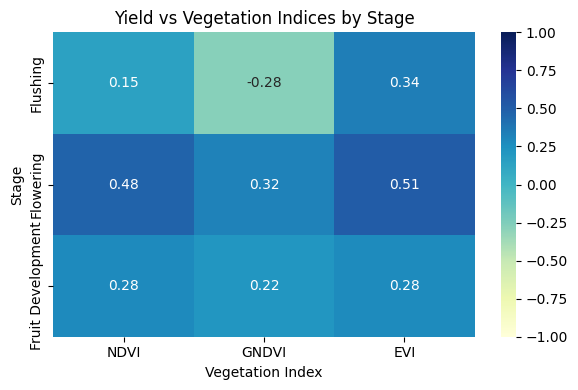

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# Load dataset
# ================================
df = pd.read_csv("/content/VIS_YIELDFinal.csv")

# ================================
# Compute stage-wise correlation between yield and VIs
# ================================
stages = ["Flushing","Flowering","Fruit Development"]
vis = ["NDVI","GNDVI","EVI"]

stage_corrs = {}

for stage in stages:
    stage_data = df[df["Stage"] == stage]

    # Correlation of yield with each VI
    corr = stage_data[vis + ["yield"]].corr().loc["yield", vis]
    stage_corrs[stage] = corr

# Convert to DataFrame
stage_corr_df = pd.DataFrame(stage_corrs).T  # Stages as rows

print(stage_corr_df)

# ================================
# Visualize as heatmap
# ================================
plt.figure(figsize=(6,4))
sns.heatmap(stage_corr_df, annot=True, cmap="YlGnBu", vmin=-1, vmax=1)
plt.title("Yield vs Vegetation Indices by Stage")
plt.ylabel("Stage")
plt.xlabel("Vegetation Index")
plt.tight_layout()
plt.savefig("Yield vs Vegetation Indices by Stage", dpi=300)
from google.colab import files
files.download("Yield vs Vegetation Indices by Stage.png")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

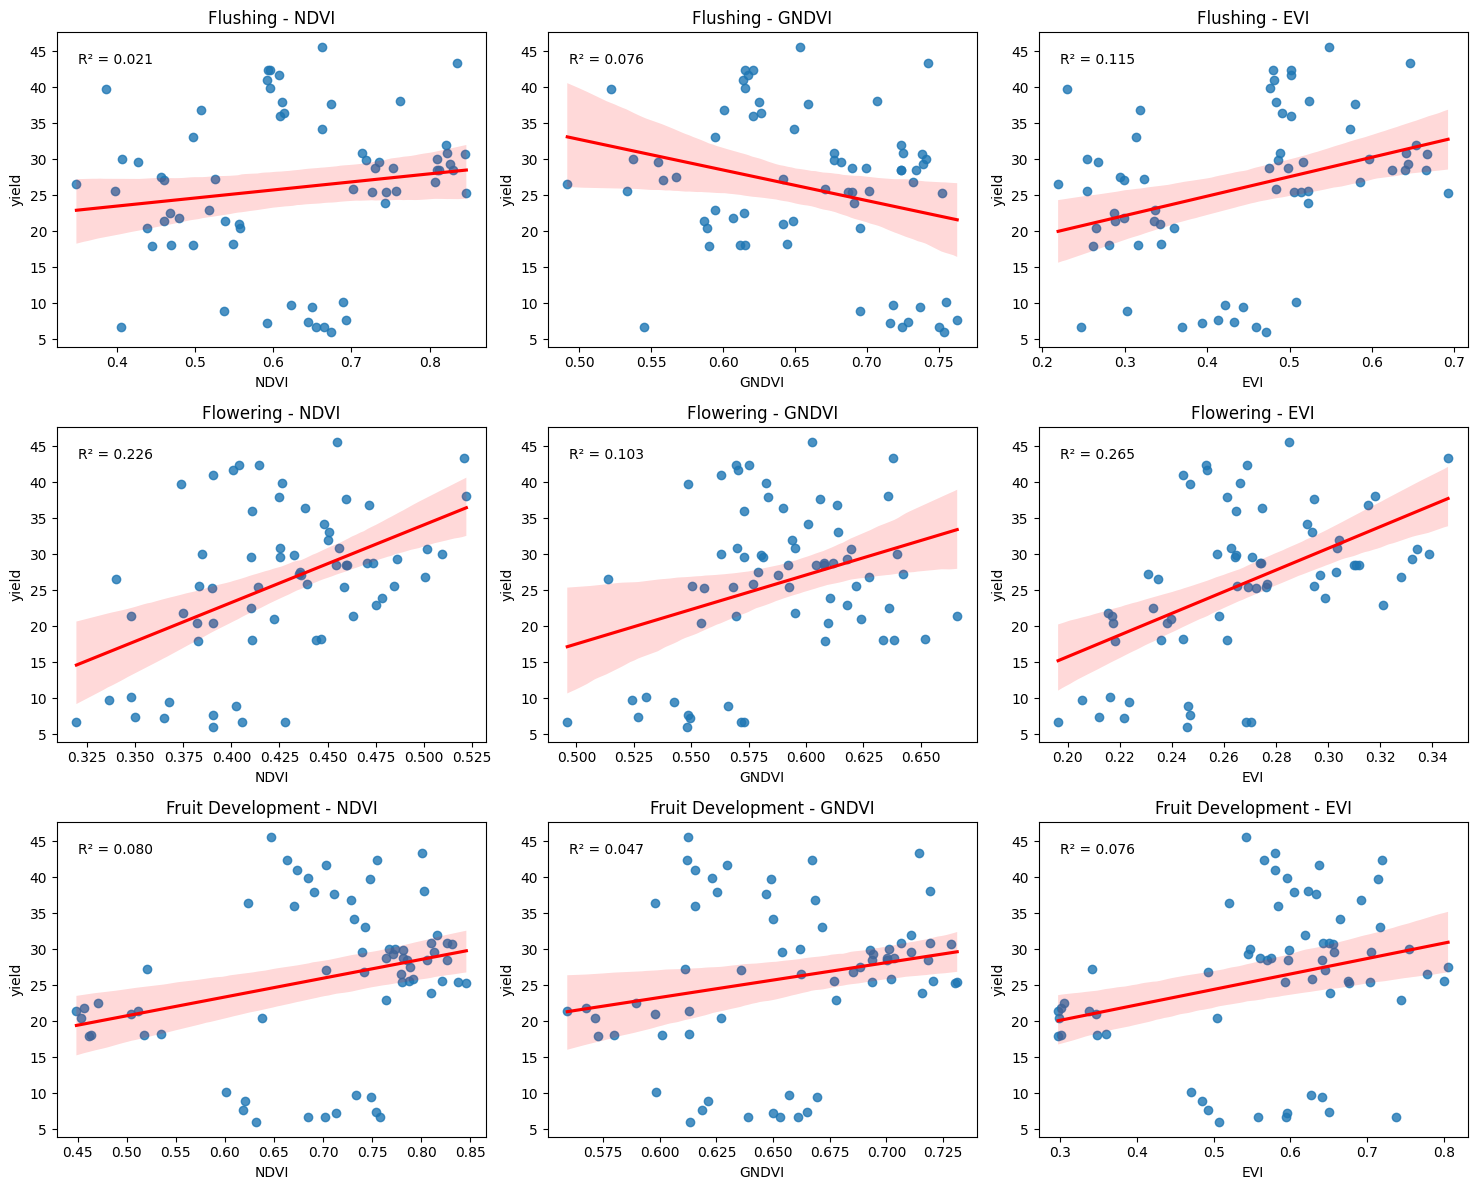

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# Load dataset
# ================================
df = pd.read_csv("/content/VIS_YIELDFinal.csv")

stages = ["Flushing","Flowering","Fruit Development"]
vis = ["NDVI","GNDVI","EVI"]

# ================================
# Scatter plots with regression for each stage
# ================================
fig, axes = plt.subplots(len(stages), len(vis), figsize=(15,12))

for i, stage in enumerate(stages):
    stage_data = df[df["Stage"] == stage]

    for j, vi in enumerate(vis):
        ax = axes[i, j]

        # Scatter with regression line
        sns.regplot(
            x=vi,
            y="yield",
            data=stage_data,
            ax=ax,
            line_kws={"color": "red"}
        )

        # Compute R²
        r = stage_data[vi].corr(stage_data["yield"])
        r2 = r**2
        ax.set_title(f"{stage} - {vi}")
        ax.text(0.05, 0.9, f"R² = {r2:.3f}", transform=ax.transAxes)

plt.tight_layout()
plt.savefig("Yield vs Vegetation Indices correlation.png", dpi=300)
from google.colab import files
files.download("Yield vs Vegetation Indices correlation.png")
plt.show()